# Notebook 02 - Sample EDA, Protocol & the Adequacy Gate

SL Report, Part 0. The audit continues on the drawn candidate sample (99,998 rows, one contiguous block in each of 40 stratified sessions), adds the relationship and baseline phases (8-9 of the EDA plan), previews the split and preprocessing protocol, and ends with the pre-registered sample-adequacy gate from [EDA_PLAN.md](../EDA_PLAN.md) section 8.

Discipline notes, stated up front: no split exists yet (`00c` runs only after this notebook's verdict). The split *preview* below uses the same seeded assignment `00c` will freeze, and the EDA baselines are fit on would-be training sessions and evaluated on would-be `VAL_STOP` sessions only. The would-be test and `VAL_CAL` sessions are not touched by anything in this notebook.

## 1. Imports & Data

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import constants as C
from common import load_raw, quiet_common_warnings, session_inventory, assign_split_sessions

quiet_common_warnings()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (9, 4)})
FIG = C.FIGURES_DIR
FIG.mkdir(parents=True, exist_ok=True)

def save_show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")
    plt.show()


In [2]:
full = load_raw()
sample = pd.read_parquet(C.PROCESSED_DIR / "sample_candidate_100k.parquet")
manifest = json.loads((C.PROCESSED_DIR / "sample_manifest.json").read_text())
print(f"full: {len(full):,} rows | sample: {len(sample):,} rows over {sample[C.SESSION_KEY].nunique()} sessions")

full: 1,330,816 rows | sample: 99,998 rows over 40 sessions


## 2. Sample Audit (compact re-run)

The notebook 01 checks that must also hold on the sample: missingness, duplicates, schema.

In [3]:
print("NaNs:", int(sample.isna().sum().sum()), "| exact duplicate rows:", int(sample.duplicated().sum()))
print("columns match full file:", list(sample.columns) == list(full.columns))
ids = sample[C.SESSION_KEY].to_numpy()
print("sessions contiguous in sample:", int((np.diff(ids) != 0).sum()) == sample[C.SESSION_KEY].nunique() - 1)

NaNs: 0 | exact duplicate rows: 0
columns match full file: True
sessions contiguous in sample: True


### Observations: The Sample Inherits the Full File's Cleanliness

Zero missing values, zero duplicates, identical schema, and each block is one contiguous run, so within-block row order still carries time.

## 3. Sample vs Full: Distributions (the plots the go-forward decision asked for)

Overlaid marginals and the per-signal quantile-shift table, the quantitative form of \"how similar are the plots and distributions\".

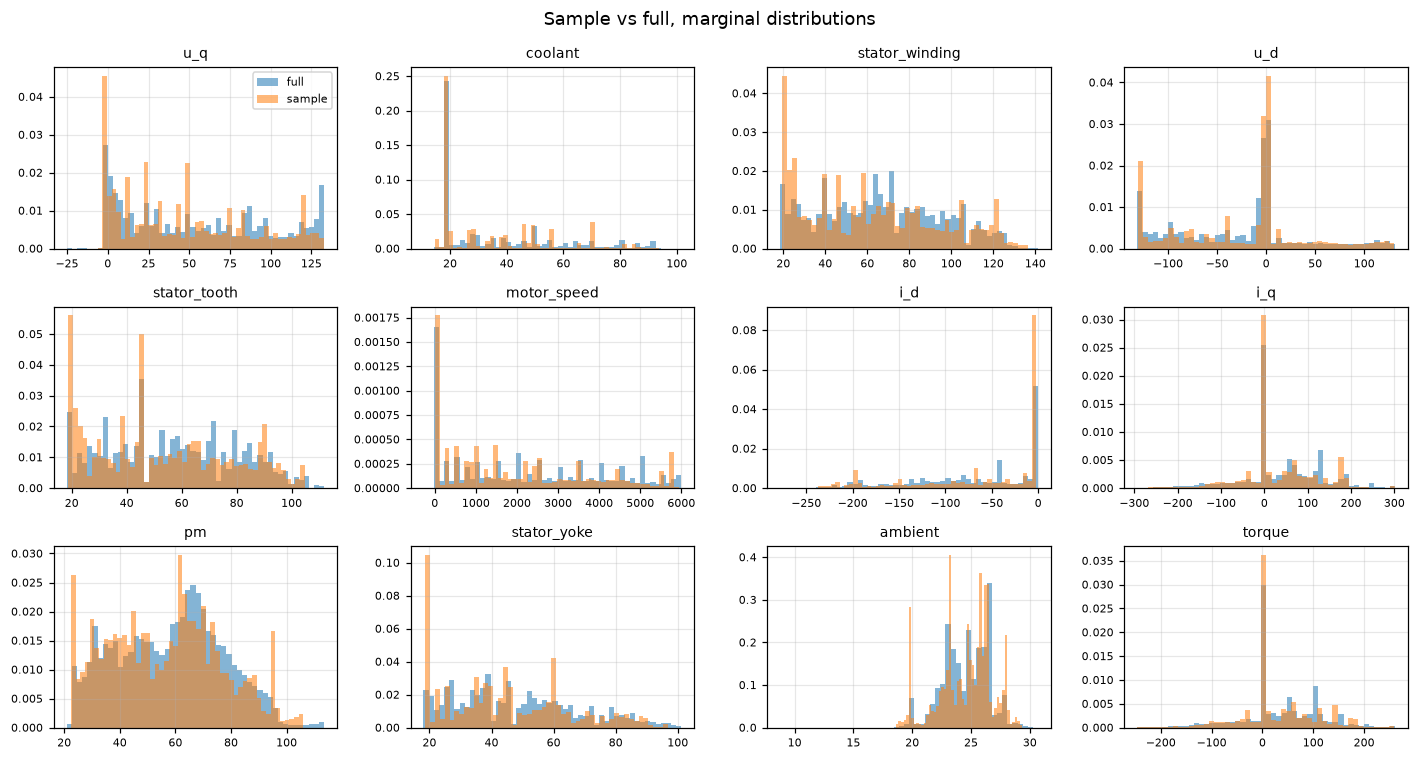

In [4]:
sig = [c for c in full.columns if c != C.SESSION_KEY]
fig, axes = plt.subplots(3, 4, figsize=(13, 7))
for ax, c in zip(axes.ravel(), sig):
    ax.hist(full[c], bins=50, density=True, alpha=0.55, label="full")
    ax.hist(sample[c], bins=50, density=True, alpha=0.55, label="sample")
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Sample vs full, marginal distributions")
save_show(fig, "02_marginals_sample_vs_full.png")

In [5]:
from common import gate_g1_envelope
g1 = gate_g1_envelope(full, sample)
shifts = pd.Series(g1["quantile_shifts"]).sort_values(ascending=False).rename("p5/p95 shift, fraction of full range")
print(shifts.round(4).to_string())
print(f"\nworst shift: {g1['g1_worst_shift']:.4f} on {g1['g1_worst_shift_signal']} (threshold {C.GATE_QUANTILE_SHIFT_MAX})")

coolant           0.1215
ambient           0.0706
u_q               0.0638
stator_winding    0.0433
pm                0.0377
i_q               0.0298
torque            0.0274
stator_tooth      0.0240
i_d               0.0228
stator_yoke       0.0211
u_d               0.0094
motor_speed       0.0000

worst shift: 0.1215 on coolant (threshold 0.05)


## 4. Sample vs Full: Operating Envelope

The speed-torque occupancy comparison behind G1's Jaccard score.

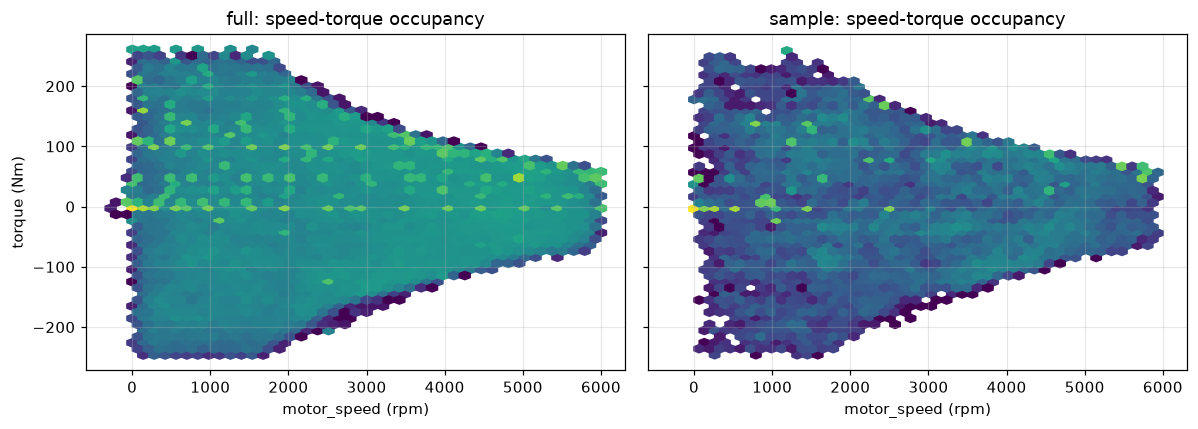

G1 occupancy Jaccard on the (20, 20) grid: 0.942 (threshold 0.9)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, (frame, name) in zip(axes, [(full, "full"), (sample, "sample")]):
    ax.hexbin(frame["motor_speed"], frame["torque"], gridsize=45, bins="log", mincnt=1)
    ax.set_title(f"{name}: speed-torque occupancy"); ax.set_xlabel("motor_speed (rpm)")
axes[0].set_ylabel("torque (Nm)")
save_show(fig, "02_envelope_sample_vs_full.png")
print(f"G1 occupancy Jaccard on the {C.GATE_ENVELOPE_GRID} grid: {g1['g1_jaccard']:.3f} (threshold {C.GATE_ENVELOPE_JACCARD_MIN})")

### Observations: Marginals Travel Well, As Expected

Stratified session selection preserves the envelope and the marginals to the eye, and the table above quantifies it per signal. G1 is the criterion marginal plots *can* see. What they cannot see is within-block temporal truncation, which is why G2 and G3 exist.

## 5. G2: Thermal-Arc Capture

The fraction of each session's `pm` excursion that its block captures. The preliminary seeded estimate was 0.21 against the 0.6 threshold, measured here on the real draw.

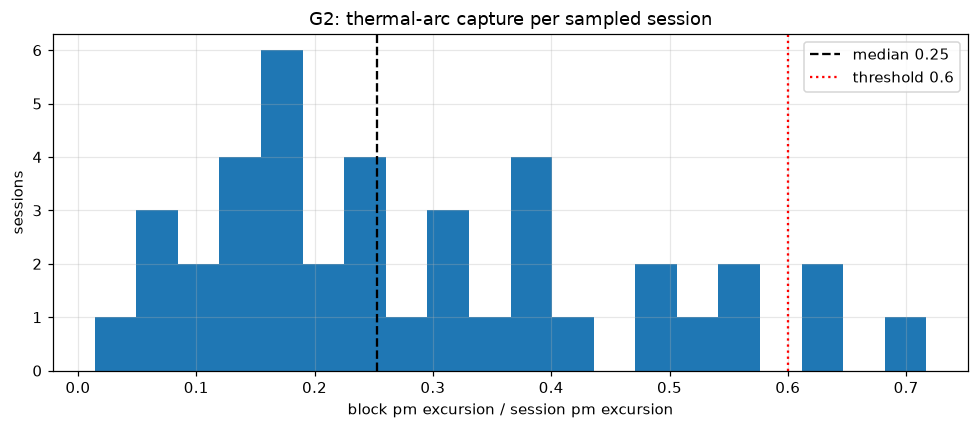

G2 median arc capture: 0.253  ->  pass: False


In [7]:
from common import gate_g2_arc_capture
g2 = gate_g2_arc_capture(full, manifest)
fig, ax = plt.subplots()
ax.hist(g2["per_session_capture"], bins=20)
ax.axvline(g2["g2_arc_capture"], color="k", ls="--", label=f"median {g2['g2_arc_capture']:.2f}")
ax.axvline(C.GATE_ARC_CAPTURE_MIN, color="r", ls=":", label=f"threshold {C.GATE_ARC_CAPTURE_MIN}")
ax.set_xlabel("block pm excursion / session pm excursion"); ax.set_ylabel("sessions"); ax.legend()
ax.set_title("G2: thermal-arc capture per sampled session")
save_show(fig, "02_g2_arc_capture.png")
print(f"G2 median arc capture: {g2['g2_arc_capture']:.3f}  ->  pass: {g2['g2_pass']}")

## 6. G3: Curvature Inside Blocks

Whether a first-order thermal response fits `pm` better than a straight line inside each block (delta-AIC of 10 or more), the conditioning check for thermal-parameter identification.

blocks with real curvature: 62% of 40 (threshold 50%)  ->  pass: True


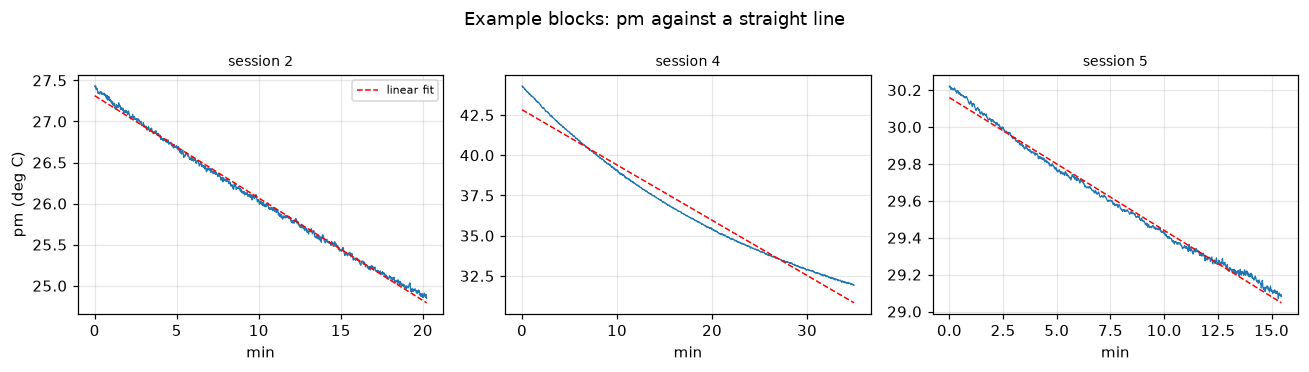

In [8]:
from common import gate_g3_curvature
g3 = gate_g3_curvature(sample)
print(f"blocks with real curvature: {g3['g3_curved_frac']*100:.0f}% of {g3['g3_blocks']} (threshold {C.GATE_CURVATURE_MIN_FRACTION*100:.0f}%)  ->  pass: {g3['g3_pass']}")
sids = sample[C.SESSION_KEY].unique()[:3]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, sid in zip(axes, sids):
    y = sample.loc[sample[C.SESSION_KEY] == sid, "pm"].to_numpy()
    t = np.arange(len(y)) / 120
    ax.plot(t, y, lw=0.8)
    ax.plot(t, np.polyval(np.polyfit(t, y, 1), t), "r--", lw=1, label="linear fit")
    ax.set_title(f"session {sid}", fontsize=9); ax.set_xlabel("min")
axes[0].set_ylabel("pm (deg C)"); axes[0].legend(fontsize=7)
fig.suptitle("Example blocks: pm against a straight line")
save_show(fig, "02_g3_example_blocks.png")

### Observations: The Temporal Criteria Measure What Histograms Cannot

G2 and G3 quantify the truncation risk the fourth review raised: blocks that ramp without approaching equilibrium fix only the ratio of thermal parameters, not the parameters. The printed numbers above are the measured truth on the real draw, and they feed the gate verdict in section 10 verbatim.

## 7. Relationships (phase 8)

Correlations, the physics pairs, and the read-only PCA glance (the real dimensionality study is ul-report's).

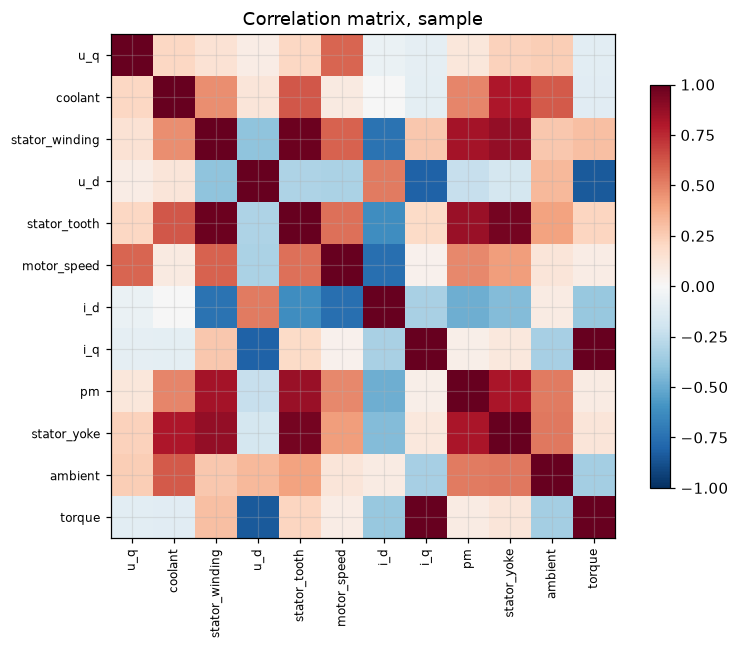

torque~i_q r = 0.9952 | pm~coolant r = 0.487 | u_q~speed r = 0.585


In [9]:
corr = sample[sig].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(sig)), sig, rotation=90, fontsize=8)
ax.set_yticks(range(len(sig)), sig, fontsize=8)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlation matrix, sample")
save_show(fig, "02_correlation_matrix.png")
print(f"torque~i_q r = {corr.loc['torque','i_q']:.4f} | pm~coolant r = {corr.loc['pm','coolant']:.3f} | u_q~speed r = {corr.loc['u_q','motor_speed']:.3f}")

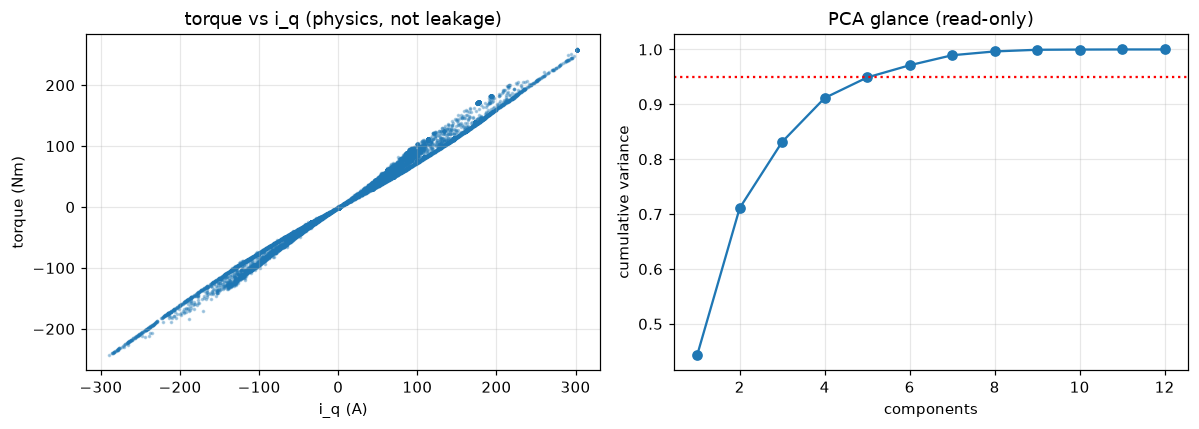

components to reach 95% variance: 6


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
idx = np.random.default_rng(0).choice(len(sample), 20000, replace=False)
axes[0].scatter(sample["i_q"].iloc[idx], sample["torque"].iloc[idx], s=2, alpha=0.3)
axes[0].set_xlabel("i_q (A)"); axes[0].set_ylabel("torque (Nm)"); axes[0].set_title("torque vs i_q (physics, not leakage)")
X = (sample[sig] - sample[sig].mean()) / sample[sig].std()
ev = np.sort(np.linalg.eigvalsh(np.cov(X.to_numpy(), rowvar=False)))[::-1]
cum = np.cumsum(ev) / ev.sum()
axes[1].plot(range(1, len(cum) + 1), cum, marker="o")
axes[1].axhline(0.95, color="r", ls=":")
axes[1].set_xlabel("components"); axes[1].set_ylabel("cumulative variance"); axes[1].set_title("PCA glance (read-only)")
save_show(fig, "02_relationships.png")
print("components to reach 95% variance:", int(np.argmax(cum >= 0.95) + 1))

### Observations: The Physics Reads Straight Out of the Correlations

- `torque` tracks `i_q` at r near 0.996 with visible reluctance spread at high current. Under the EDA guide's rules this is a too-perfect-relationship red flag, and here it is the dq torque equation doing exactly what it must: physics, not leakage. Sign disagreements concentrate near zero torque where noise dominates.
- `pm`~`coolant` at r near 0.47 is the confound the risk register carries: load profiles drive both, so no causal reading is allowed.
- The PCA glance lands near six components for 95 % variance on the raw signals. This is a reported diagnostic (the tripwire has no PCA threshold by design), and it is an early, honest signal against ul's frozen H2 expectation of 3-4, to be resolved properly in ul-report.

## 8. Split Preview & Preprocessing Plan (protocol)

The seeded assignment `00c` will freeze, previewed with the identical function, plus the preprocessing decisions justified on would-be training sessions only.

In [11]:
split = assign_split_sessions(sorted(int(s) for s in manifest["sessions"]))
for k, v in split.items():
    print(f"{k:>9} ({len(v):>2}): {v}")
train_ids = split["train"]
train_df = sample[sample[C.SESSION_KEY].isin(train_ids)]
ac = [pd.Series(g["pm"].to_numpy()).autocorr(lag) for lag in (1, 120, 600, 1200) for _, g in [(None, train_df)]]
print(f"\npm autocorrelation on would-be train at lags 0.5s/1min/5min/10min: " + ", ".join(f"{v:.3f}" for v in ac))
print(f"EWMA span grid (samples at 2 Hz): {C.EWMA_SPAN_GRID} = 4 s to ~8.5 min")

    train (19): [2, 8, 10, 11, 16, 26, 29, 30, 32, 47, 48, 53, 56, 60, 63, 66, 73, 75, 79]
 val_stop ( 3): [24, 61, 72]
  val_cal ( 9): [4, 13, 20, 44, 64, 67, 70, 71, 76]
     test ( 9): [5, 9, 36, 41, 43, 55, 57, 58, 59]

pm autocorrelation on would-be train at lags 0.5s/1min/5min/10min: 1.000, 0.962, 0.801, 0.613
EWMA span grid (samples at 2 Hz): (8, 64, 256, 1024) = 4 s to ~8.5 min


### Observations: The Preprocessing Plan, Frozen For 00c

- Split preview: 19/3/9/9 sessions as pre-registered, deterministic under `SPLIT_SEED`, so this exact assignment is what `00c` records.
- `pm` autocorrelation stays high out to the 10-minute lag on would-be training data, which is the empirical justification for the EWMA span grid reaching ~8.5 minutes: the spans bracket the memory the pointwise rungs need.
- Plan, applied later by `00c` and `features.py`: standardize all continuous signals on training statistics only, EWMA features per input signal at the grid spans resetting at session boundaries, no other transforms (section 10 of notebook 01 found none warranted), and zero imputation because there is nothing to impute.

## 9. EDA Baselines (phase 9, the floor every rung must clear)

Three deliberately simple baselines, fit on would-be train, evaluated on would-be `VAL_STOP`. Would-be test and `VAL_CAL` stay untouched.

In [12]:
vs_df = sample[sample[C.SESSION_KEY].isin(split["val_stop"])]
rows = []
# persistence at 1 step and 5 minutes
for name, lag in [("persistence 0.5 s", 1), ("persistence 5 min", 600)]:
    errs = []
    for _, g in vs_df.groupby(C.SESSION_KEY):
        y = g["pm"].to_numpy()
        if len(y) > lag:
            errs.append(np.abs(y[lag:] - y[:-lag]))
    e = np.concatenate(errs)
    rows.append({"baseline": name, "target": "pm", "val_stop_mae": float(e.mean())})
# ambient anchor: linear on coolant+ambient
Xtr = train_df[["coolant", "ambient"]].to_numpy(); ytr = train_df["pm"].to_numpy()
A = np.c_[Xtr, np.ones(len(Xtr))]
w, *_ = np.linalg.lstsq(A, ytr, rcond=None)
Xvs = np.c_[vs_df[["coolant", "ambient"]].to_numpy(), np.ones(len(vs_df))]
rows.append({"baseline": "ambient anchor (linear)", "target": "pm",
             "val_stop_mae": float(np.abs(Xvs @ w - vs_df["pm"].to_numpy()).mean())})
# physics one-liner: torque from i_q
k, *_ = np.linalg.lstsq(train_df[["i_q"]].to_numpy(), train_df["torque"].to_numpy(), rcond=None)
rows.append({"baseline": "torque = k*i_q (least squares)", "target": "torque",
             "val_stop_mae": float(np.abs(vs_df["i_q"].to_numpy() * k[0] - vs_df["torque"].to_numpy()).mean())})
base = pd.DataFrame(rows)
base.to_csv(C.TABLES_DIR / "eda_baselines.csv", index=False)
base

,baseline,target,val_stop_mae
0,persistence 0.5 s,pm,0.055153
1,persistence 5 min,pm,6.034812
2,ambient anchor (linear),pm,18.555112
3,torque = k*i_q (least squares),torque,5.411332


### Observations: The Floor, And the Trap Stated In Advance

- One-step persistence looks spectacular because slow states make trivial predictors look strong, the leakage-smell lesson pre-registered in the EDA plan. It is a sanity anchor, never a claim of skill. The 5-minute horizon is the honest persistence floor.
- The ambient anchor shows what no electrical information buys. The gap between it and the model ladder is what electrical signals plus physics are worth.
- The torque one-liner lands near-perfect from `i_q` alone, physics again, and the residual against the full torque equation is what `i_d` and reluctance add. Every Part 2 rung must clear these numbers to earn its complexity.

## 10. Risk Register & Gate Verdict

The guide's risk register, then the pre-registered gate, evaluated and persisted.

In [13]:
risks = pd.DataFrame([
    {"risk": "pm~coolant confound (load drives both)", "kind": "confound", "handling": "no causal reading, noted for xai attribution reading"},
    {"risk": "constant-torque soak segments up to 134 min", "kind": "data quirk", "handling": "classified as test design (nb01 section 6), sessions kept"},
    {"risk": "implicit 2 Hz clock, no timestamp column", "kind": "assumption", "handling": "recorded in data dictionary, consistency-checked against thermal timescales"},
    {"risk": "block truncation of thermal arcs", "kind": "sampling", "handling": "measured by G2/G3 below, gate decides"},
    {"risk": "one-step persistence looks strong on slow targets", "kind": "evaluation", "handling": "5-min persistence is the quoted floor, 1-step reported as anchor only"},
    {"risk": "session-shift gap between train and validation", "kind": "distribution shift", "handling": "tripwire uses self-calibrating 3x median-gap trigger"},
])
risks.to_csv(C.TABLES_DIR / "eda_risk_register.csv", index=False)
risks

,risk,kind,handling
0,pm~coolant confound (load drives both),confound,"no causal reading, noted for xai attribution r..."
1,constant-torque soak segments up to 134 min,data quirk,"classified as test design (nb01 section 6), se..."
2,"implicit 2 Hz clock, no timestamp column",assumption,"recorded in data dictionary, consistency-check..."
3,block truncation of thermal arcs,sampling,"measured by G2/G3 below, gate decides"
4,one-step persistence looks strong on slow targets,evaluation,"5-min persistence is the quoted floor, 1-step ..."
5,session-shift gap between train and validation,distribution shift,tripwire uses self-calibrating 3x median-gap t...


In [14]:
from common import evaluate_gate, save_gate_verdict
gate = evaluate_gate(full, sample, manifest)
v = gate["verdict"]
save_gate_verdict(v)
print(f"G1 envelope: jaccard {v['g1_jaccard']:.3f} (>= {C.GATE_ENVELOPE_JACCARD_MIN}), worst shift {v['g1_worst_shift']:.4f} on {v['g1_worst_shift_signal']} (<= {C.GATE_QUANTILE_SHIFT_MAX})  ->  {'PASS' if v['g1_pass'] else 'FAIL'}")
print(f"G2 arc capture: median {v['g2_arc_capture']:.3f} (>= {C.GATE_ARC_CAPTURE_MIN})  ->  {'PASS' if v['g2_pass'] else 'FAIL'}")
print(f"G3 curvature: {v['g3_curved_frac']*100:.0f}% of blocks (>= {C.GATE_CURVATURE_MIN_FRACTION*100:.0f}%)  ->  {'PASS' if v['g3_pass'] else 'FAIL'}")
print(f"\nGATE: {'PASS - the 100k spec stands, 00c may run' if v['gate_pass'] else 'FAIL - execution pauses, the decision returns to the user (keep 100k with disclosed limitations, or move to the full dataset)'}")

[00:30:33] saved   gate verdict -> data/processed/gate_verdict.json


G1 envelope: jaccard 0.942 (>= 0.9), worst shift 0.1215 on coolant (<= 0.05)  ->  FAIL
G2 arc capture: median 0.253 (>= 0.6)  ->  FAIL
G3 curvature: 62% of blocks (>= 50%)  ->  PASS

GATE: FAIL - execution pauses, the decision returns to the user (keep 100k with disclosed limitations, or move to the full dataset)


## 11. Modeling-Readiness Verdict

The audit itself found a clean, well-understood dataset: the deliverables (`eda_data_dictionary.csv`, `eda_quality_report` via the session-quality table, `eda_risk_register.csv`, `eda_baselines.csv`, the gate verdict JSON) are all written. Readiness therefore reduces to the gate printout above, exactly as pre-registered: if it reads PASS, `00c` freezes this notebook's split preview and confirmatory work begins. If it reads FAIL, nothing downstream runs until the user's decision is recorded, and this notebook's numbers are the evidence that decision is made on. No hypothesis was touched by anything seen here, and the frozen files remain byte-stable.